In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, re
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

In [2]:
root = Path("..")

In [3]:
DATASET_DIR = root / "data" / 'processed'
DATASET_PATH = DATASET_DIR / "processed_df_1.csv"
DATASET_DIR.exists(), DATASET_PATH.exists() # must be True

(True, True)

In [4]:
df = pd.read_csv(DATASET_PATH)
df.head()

,role,message_number,sentence_number,sentence,tag,dialogue_number,sentence_clean
0,Proponent,0,1,What is the type of knowledge that is injected...,ask_info,0,what is the type of knowledge that is injected...
1,Domain Expert,1,1,We inject domain knowledge from Constrained Sa...,reply_info,0,we inject domain knowledge from constrained sa...
2,Proponent,2,0,Interesting!,give_opinion,0,interesting!
3,Proponent,2,1,What is the problem used to perform the experi...,ask_info,0,what is the problem used to perform the experi...
4,Domain Expert,3,0,We employ the Partial Latin Square completion ...,reply_info,0,we employ the partial latin square completion ...


In [5]:
required_columns = ["dialogue_number", "sentence_clean", "tag"]
optional_order_columns = ["message_number", "sentence_number"]
optional_feature_columns = ["role"]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

In [6]:
df_temp = df.copy(deep=True)

In [7]:
print(df_temp.shape)
print(df_temp["tag"].value_counts())

(750, 7)
tag
reply_info        322
ask_info          221
give_opinion      123
ask_rebuttal       49
ask_suggestion     35
Name: count, dtype: int64


- Note: MEMM is implemented as a simple classifier that predicts the current label using the previous label and current observation features. So we need to perform some feature extraction.

- Note: MEMM should use rich observation features; otherwise it behaves close to an HMM using mostly tag history.

#### Basic text features

In [58]:
# handcrafted text features with wh-words, modal/request markers,negation/disagreement markers, pronoun cues, punctuation cues, and unigram+bigram BoW.
def basic_text_features(text):
    raw_text = str(text)
    text = raw_text.lower().strip()
    tokens = re.findall(r"[a-zA-Z']+", text)

    features = {}

    features["bias"] = 1
    features["num_tokens"] = len(tokens)
    features["char_len"] = len(text)
    features["has_question_mark"] = int("?" in raw_text)
    features["has_exclamation"] = int("!" in raw_text)
    features["question_mark_count"] = raw_text.count("?")

    first_token = tokens[0] if tokens else "<EMPTY>"
    features[f"first_token={first_token}"] = 1

    wh_words = {"what", "why", "how", "when", "where", "who", "which"}
    aux_question_starters = {"do", "does", "did", "is", "are", "was", "were", "can", "could", "would", "should"}
    features["starts_with_wh"] = int(first_token in wh_words)
    features["starts_with_aux_question"] = int(first_token in aux_question_starters)

    opinion_markers = [
        "i think", "i believe", "i feel", "in my opinion", "to me", "seems", "seem",
        "interesting", "promising", "strong", "weak", "better", "worse", "useful"
    ]

    rebuttal_markers = [
        "but", "however", "although", "still", "do you think", "are you sure",
        "not sure", "i disagree", "isn't", "doesn't", "why not", "on the other hand"
    ]

    suggestion_markers = [
        "should", "could", "would", "maybe", "try", "recommend", "suggest",
        "consider", "you can", "we can", "it may be better"
    ]

    info_request_markers = [
        "what", "why", "how", "when", "where", "who", "which", "can you", "could you",
        "do you know", "tell me", "explain", "clarify"
    ]

    answer_markers = [
        "yes", "no", "because", "therefore", "it is", "this is", "that is", "the answer"
    ]

    topic_markers = [
        "next", "another", "move", "switch", "turn to", "let us discuss", "let's discuss"
    ]

    marker_groups = {
        "opinion": opinion_markers,
        "rebuttal": rebuttal_markers,
        "suggestion": suggestion_markers,
        "info_request": info_request_markers,
        "answer": answer_markers,
        "topic": topic_markers,
    }

    for group_name, markers in marker_groups.items():
        features[f"has_{group_name}_marker"] = int(any(m in text for m in markers))

    features["has_first_person"] = int(any(tok in {"i", "me", "my", "mine", "we", "our"} for tok in tokens))
    features["has_second_person"] = int(any(tok in {"you", "your", "yours"} for tok in tokens))
    features["has_negation"] = int(any(tok in {"not", "no", "never", "n't"} for tok in tokens))

    # Lightweight BoW: unigrams and adjacent bigrams.
    for token in tokens:
        features[f"word={token}"] = 1

    for w1, w2 in zip(tokens, tokens[1:]):
        features[f"bigram={w1}_{w2}"] = 1

    return features

#### Advanced text features extraction

In [8]:
import re
from typing import Optional

def extract_features(
    text: str,
    turn_idx: int = 0,
    total_turns: int = 1,
    speaker_role: Optional[str] = None,
    prev_text: Optional[str] = None,
    prev_tag: Optional[str] = None,
    next_text: Optional[str] = None,
) -> dict:
    """
    Feature extraction for MEMM dialogue act tagging.

    Args:
        text:         Current utterance text.
        turn_idx:     Index of this turn in the conversation (0-based).
        total_turns:  Total number of turns in the conversation.
        speaker_role: Speaker role string e.g. 'DOMAIN_EXPERT' or 'PROPONENT'.
        prev_text:    Text of the previous utterance (or None).
        prev_tag:     Predicted tag of the previous utterance (or None).
        next_text:    Text of the next utterance (or None, for lookahead).
    """

    # ------------------------------------------------------------------ #
    #  0. Normalise current utterance                                      #
    # ------------------------------------------------------------------ #
    raw_text = str(text)
    clean    = raw_text.lower().strip()
    tokens   = re.findall(r"[a-zA-Z']+", clean)
    n_tokens = len(tokens)

    features = {}

    # ------------------------------------------------------------------ #
    #  1. Bias & surface statistics                                        #
    # ------------------------------------------------------------------ #
    features["bias"]            = 1
    features["num_tokens"]      = n_tokens
    features["char_len"]        = len(clean)
    features["avg_token_len"]   = (sum(len(t) for t in tokens) / n_tokens) if n_tokens else 0

    # ------------------------------------------------------------------ #
    #  2. Punctuation cues                                                 #
    # ------------------------------------------------------------------ #
    features["has_question_mark"]      = int("?" in raw_text)
    features["has_exclamation"]        = int("!" in raw_text)
    features["question_mark_count"]    = raw_text.count("?")
    features["exclamation_count"]      = raw_text.count("!")
    features["has_ellipsis"]           = int("..." in raw_text)

    # ------------------------------------------------------------------ #
    #  3. First / last token cues                                          #
    # ------------------------------------------------------------------ #
    first_token = tokens[0]  if tokens else "<EMPTY>"
    last_token  = tokens[-1] if tokens else "<EMPTY>"
    features[f"first_token={first_token}"] = 1
    features[f"last_token={last_token}"]   = 1

    wh_words = {"what", "why", "how", "when", "where", "who", "which"}
    aux_starters = {
        "do", "does", "did", "is", "are", "was", "were",
        "can", "could", "would", "should", "will", "shall", "might", "may"
    }
    features["starts_with_wh"]  = int(first_token in wh_words)
    features["starts_with_aux"] = int(first_token in aux_starters)
    features["ends_with_right"] = int(last_token in {"right", "correct", "yes", "no"})

    # ------------------------------------------------------------------ #
    #  4. Pronoun cues                                                     #
    # ------------------------------------------------------------------ #
    first_person  = {"i", "me", "my", "mine", "we", "our", "ours", "us"}
    second_person = {"you", "your", "yours"}
    third_person  = {"he", "she", "they", "it", "his", "her", "their", "its"}

    features["has_first_person"]  = int(any(t in first_person  for t in tokens))
    features["has_second_person"] = int(any(t in second_person for t in tokens))
    features["has_third_person"]  = int(any(t in third_person  for t in tokens))

    fp_count = sum(1 for t in tokens if t in first_person)
    features["first_person_ratio"] = fp_count / n_tokens if n_tokens else 0

    # ------------------------------------------------------------------ #
    #  5. Negation                                                         #
    # ------------------------------------------------------------------ #
    negation_tokens = {"not", "no", "never", "neither", "nor", "nobody", "nothing", "nowhere"}
    features["has_negation"]    = int(any(t in negation_tokens for t in tokens)
                                      or "n't" in clean)
    features["negation_count"]  = sum(1 for t in tokens if t in negation_tokens)

    # ------------------------------------------------------------------ #
    #  6. WH-word density                                                  #
    # ------------------------------------------------------------------ #
    wh_count = sum(1 for t in tokens if t in wh_words)
    features["wh_word_count"] = wh_count
    features["wh_word_ratio"] = wh_count / n_tokens if n_tokens else 0

    # ------------------------------------------------------------------ #
    #  7. Marker groups (binary + count, no overlapping sets)              #
    # ------------------------------------------------------------------ #

    # --- 7a. Info-request markers (questions only — no modal overlap) ---
    info_request_markers = [
        "can you", "could you", "do you know", "tell me",
        "explain", "clarify", "please describe", "what is",
        "what are", "how does", "why does", "who is"
    ]

    # --- 7b. Suggestion markers ---
    suggestion_markers = [
        "should", "maybe", "try", "recommend", "suggest",
        "consider", "you can", "we can", "it may be better",
        "it would be better", "one option", "another option",
        "have you tried", "you might want"
    ]

    # --- 7c. Opinion / evaluation markers ---
    opinion_markers = [
        "i think", "i believe", "i feel", "in my opinion",
        "to me", "seems", "seem", "interesting", "promising",
        "strong", "weak", "better", "worse", "useful",
        "important", "significant", "impressive", "concerning"
    ]

    # --- 7d. Strong rebuttal markers ---
    strong_rebuttal_markers = [
        "i disagree", "that's not", "are you sure", "not necessarily",
        "on the contrary", "actually,", "in fact,", "i don't think",
        "that doesn't", "isn't that", "wouldn't that", "i'm not sure",
        "do you really", "that may not"
    ]

    # --- 7e. Weak / transitional rebuttal markers ---
    weak_rebuttal_markers = [
        "but", "however", "although", "still", "yet",
        "on the other hand", "even so", "that said"
    ]

    # --- 7f. Answer / reply markers ---
    answer_markers = [
        "yes", "no", "because", "therefore", "it is",
        "this is", "that is", "the answer", "indeed",
        "exactly", "correct", "precisely", "absolutely"
    ]

    # --- 7g. Topic-transition markers ---
    topic_markers = [
        "next", "another", "move on", "switch", "turn to",
        "let us discuss", "let's discuss", "moving on",
        "the next point", "shifting to"
    ]

    # --- 7h. Stance markers (opinion vs. factual reply) ---
    positive_stance  = ["good", "great", "agree", "correct", "right", "exactly", "well done"]
    negative_stance  = ["bad", "wrong", "disagree", "incorrect", "unfortunately", "sadly"]
    hedging_markers  = [
        "maybe", "perhaps", "might", "possibly",
        "i think", "i believe", "seems like", "it appears"
    ]

    marker_groups = {
        "info_request":    info_request_markers,
        "suggestion":      suggestion_markers,
        "opinion":         opinion_markers,
        "strong_rebuttal": strong_rebuttal_markers,
        "weak_rebuttal":   weak_rebuttal_markers,
        "answer":          answer_markers,
        "topic":           topic_markers,
        "positive_stance": positive_stance,
        "negative_stance": negative_stance,
        "hedging":         hedging_markers,
    }

    for group_name, markers in marker_groups.items():
        hits = sum(1 for m in markers if m in clean)
        features[f"has_{group_name}"]   = int(hits > 0)
        features[f"count_{group_name}"] = hits

    # Combined rebuttal signal
    features["has_any_rebuttal"] = int(
        features["has_strong_rebuttal"] or features["has_weak_rebuttal"]
    )

    # ------------------------------------------------------------------ #
    #  8. Speaker role                                                     #
    # ------------------------------------------------------------------ #
    if speaker_role is not None:
        role_clean = str(speaker_role).upper().strip()
        features[f"speaker_role={role_clean}"] = 1
        features["is_domain_expert"] = int("DOMAIN_EXPERT" in role_clean)
        features["is_proponent"]     = int("PROPONENT"     in role_clean)
    else:
        features["is_domain_expert"] = 0
        features["is_proponent"]     = 0

    # ------------------------------------------------------------------ #
    #  9. Conversation position                                            #
    # ------------------------------------------------------------------ #
    features["turn_index"]        = turn_idx
    features["is_first_turn"]     = int(turn_idx == 0)
    features["is_last_turn"]      = int(turn_idx == total_turns - 1)
    features["relative_position"] = turn_idx / total_turns if total_turns else 0

    # ------------------------------------------------------------------ #
    # 10. Previous-tag context  (MEMM's key advantage over HMM)           #
    # ------------------------------------------------------------------ #
    if prev_tag is not None:
        features[f"prev_tag={prev_tag}"] = 1

        # Bigram: (prev_tag, current first token)
        features[f"prev_tag={prev_tag}&first_token={first_token}"] = 1

        # Bigram: (prev_tag, starts_with_wh)
        features[f"prev_tag={prev_tag}&starts_with_wh={features['starts_with_wh']}"] = 1

        # Bigram: (prev_tag, has_question_mark)
        features[f"prev_tag={prev_tag}&has_question={features['has_question_mark']}"] = 1

        # Bigram: (prev_tag, speaker_role) — very powerful for reply_info
        if speaker_role is not None:
            features[f"prev_tag={prev_tag}&speaker={role_clean}"] = 1
    else:
        features["prev_tag=<START>"] = 1

    # ------------------------------------------------------------------ #
    # 11. Previous-utterance text features                                 #
    # ------------------------------------------------------------------ #
    if prev_text is not None:
        prev_raw    = str(prev_text)
        prev_clean  = prev_raw.lower().strip()
        prev_tokens = re.findall(r"[a-zA-Z']+", prev_clean)

        features["prev_has_question_mark"] = int("?" in prev_raw)
        features["prev_num_tokens"]        = len(prev_tokens)
        features["prev_starts_with_wh"]    = int(
            bool(prev_tokens) and prev_tokens[0] in wh_words
        )
        features[f"prev_first_token={prev_tokens[0] if prev_tokens else '<EMPTY>'}"] = 1

        # Did the previous turn look like a question?
        features["prev_looks_like_question"] = int(
            features["prev_has_question_mark"] or features["prev_starts_with_wh"]
        )
    else:
        features["prev_has_question_mark"]   = 0
        features["prev_num_tokens"]          = 0
        features["prev_starts_with_wh"]      = 0
        features["prev_looks_like_question"] = 0

    # ------------------------------------------------------------------ #
    # 12. Next-utterance lookahead (optional, use only if available)       #
    # ------------------------------------------------------------------ #
    if next_text is not None:
        next_raw    = str(next_text)
        next_clean  = next_raw.lower().strip()
        next_tokens = re.findall(r"[a-zA-Z']+", next_clean)

        features["next_has_question_mark"] = int("?" in next_raw)
        features["next_num_tokens"]        = len(next_tokens)
        features["next_starts_with_wh"]    = int(
            bool(next_tokens) and next_tokens[0] in wh_words
        )
    else:
        features["next_has_question_mark"] = 0
        features["next_num_tokens"]        = 0
        features["next_starts_with_wh"]    = 0

    # ------------------------------------------------------------------ #
    # 13. Lightweight BoW — unigrams + bigrams                            #
    # ------------------------------------------------------------------ #
    for token in tokens:
        features[f"word={token}"] = 1

    for w1, w2 in zip(tokens, tokens[1:]):
        features[f"bigram={w1}_{w2}"] = 1

    return features

- Note: We are also adding the previous label information with the features because MEMM uses sequence information.

In [9]:
def row_to_features(row, prev_tag, prev_text=None, next_text=None):
    
    # Map row fields to extract_features arguments
    speaker_role = None
    if "role" in row.index and pd.notna(row["role"]):
        speaker_role = str(row["role"])

    prev_role = None
    if "_prev_role" in row.index and pd.notna(row["_prev_role"]):
        prev_role = str(row["_prev_role"])

    turn_idx     = int(row["_sent_position"]) if "_sent_position" in row.index else 0
    total_turns  = int(row["_total_turns"])   if "_total_turns"   in row.index else 1

    features = extract_features(
        text         = row["sentence_clean"],
        turn_idx     = turn_idx,
        total_turns  = total_turns,
        speaker_role = speaker_role,
        prev_text    = prev_text,
        prev_tag     = prev_tag,
        next_text    = next_text,
    )

    # Speaker-change signal — kept here since it's a row-level flag, not derivable from text alone
    if "_speaker_changed" in row.index:
        features["speaker_changed"] = int(row["_speaker_changed"])

    # Previous role — conjoin with current role for transition context
    if prev_role is not None:
        features[f"prev_role={prev_role}"] = 1
        if speaker_role is not None:
            features[f"role_transition={prev_role}->{speaker_role}"] = 1

    return features

- Note: MEMM's key idea is that the current intent tag depends on the previous tag and the features extracted from the current sentence/observation.

In [10]:
sort_cols = [col for col in ["dialogue_number", "message_number", "sentence_number"] if col in df_temp.columns]

def sort_dialogue(group):
    return group.sort_values(sort_cols).reset_index(drop=True)

def add_sequence_context(group):
    group = sort_dialogue(group).copy()
    group["_sent_position"] = np.arange(len(group))

    if "role" in group.columns:
        group["_prev_role"] = group["role"].shift(1).fillna("START")
        group["_speaker_changed"] = (group["role"] != group["role"].shift(1)).astype(int)
        group.loc[0, "_speaker_changed"] = 0
    else:
        group["_prev_role"] = "START"
        group["_speaker_changed"] = 0

    return group

def make_memm_training_data(data):
    X_features = []
    y_labels = []

    for _, group in data.groupby("dialogue_number"):
        group = add_sequence_context(group)

        prev_tag = "START"

        for _, row in group.iterrows():
            features = row_to_features(row, prev_tag)

            X_features.append(features)
            y_labels.append(row["tag"])

            # During training, update with the gold label.
            prev_tag = row["tag"]

    return X_features, y_labels

- Example: features = sentence features + prev_tag=START, label = ask_info

In [11]:
dialogue_ids = df_temp["dialogue_number"].unique()

In [12]:
train_ids, test_ids = train_test_split(
    dialogue_ids,
    test_size=0.2,
    random_state=42
)

In [13]:
train_df = df_temp[df_temp["dialogue_number"].isin(train_ids)].copy()
test_df = df_temp[df_temp["dialogue_number"].isin(test_ids)].copy()

In [14]:
print("Train dialogues:", train_df["dialogue_number"].nunique())
print("Test dialogues:", test_df["dialogue_number"].nunique())

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

assert set(train_df["dialogue_number"]).isdisjoint(set(test_df["dialogue_number"]))

Train dialogues: 32
Test dialogues: 9
Train rows: 574
Test rows: 176


In [15]:
X_train_features, y_train = make_memm_training_data(train_df)

In [16]:
print("Number of training instances:", len(X_train_features))
print("Number of labels:", len(y_train))

print("Example feature dictionary:")
X_train_features[1]

Number of training instances: 574
Number of labels: 574
Example feature dictionary:


{'bias': 1,
 'num_tokens': 8,
 'char_len': 66,
 'avg_token_len': 7.25,
 'has_question_mark': 0,
 'has_exclamation': 0,
 'question_mark_count': 0,
 'exclamation_count': 0,
 'has_ellipsis': 0,
 'first_token=we': 1,
 'last_token=problems': 1,
 'starts_with_wh': 0,
 'starts_with_aux': 0,
 'ends_with_right': 0,
 'has_first_person': 1,
 'has_second_person': 0,
 'has_third_person': 0,
 'first_person_ratio': 0.125,
 'has_negation': 0,
 'negation_count': 0,
 'wh_word_count': 0,
 'wh_word_ratio': 0.0,
 'has_info_request': 0,
 'count_info_request': 0,
 'has_suggestion': 0,
 'count_suggestion': 0,
 'has_opinion': 0,
 'count_opinion': 0,
 'has_strong_rebuttal': 0,
 'count_strong_rebuttal': 0,
 'has_weak_rebuttal': 0,
 'count_weak_rebuttal': 0,
 'has_answer': 1,
 'count_answer': 1,
 'has_topic': 0,
 'count_topic': 0,
 'has_positive_stance': 0,
 'count_positive_stance': 0,
 'has_negative_stance': 0,
 'count_negative_stance': 0,
 'has_hedging': 0,
 'count_hedging': 0,
 'has_any_rebuttal': 0,
 'speaker

#### Vectorizing features

In [17]:
vectorizer = DictVectorizer(sparse=True)

In [18]:
X_train = vectorizer.fit_transform(X_train_features)
print("Training matrix shape:", X_train.shape)

Training matrix shape: (574, 5556)


#### Train the MEMM classifier

In [19]:
memm_clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs",
    C=0.5
)

In [20]:
memm_clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

#### Greedy decoding

In [21]:
def predict_dialogue_greedy(model, vectorizer, dialogue_df):
    dialogue_df = add_sequence_context(dialogue_df)

    predictions = []
    prev_tag = "START"

    for _, row in dialogue_df.iterrows():
        features = row_to_features(row, prev_tag)
        X = vectorizer.transform([features])

        pred_tag = model.predict(X)[0]
        predictions.append(pred_tag)

        # During testing, update with predicted label.
        prev_tag = pred_tag

    return predictions


def predict_dialogue_viterbi(model, vectorizer, dialogue_df, labels):
    dialogue_df = add_sequence_context(dialogue_df)
    labels = list(labels)
    n = len(dialogue_df)

    if n == 0:
        return []

    # dp[t][label] = best log-score ending in `label` at position t.
    dp = []
    backpointers = []

    for t, (_, row) in enumerate(dialogue_df.iterrows()):
        current_scores = {}
        current_backptr = {}

        prev_candidates = ["START"] if t == 0 else labels

        for curr_label in labels:
            best_score = -np.inf
            best_prev = None

            for prev_label in prev_candidates:
                features = row_to_features(row, prev_label)
                X = vectorizer.transform([features])

                class_index = list(model.classes_).index(curr_label)
                log_prob = model.predict_log_proba(X)[0, class_index]

                previous_score = 0.0 if t == 0 else dp[t - 1][prev_label]
                score = previous_score + log_prob

                if score > best_score:
                    best_score = score
                    best_prev = prev_label

            current_scores[curr_label] = best_score
            current_backptr[curr_label] = best_prev

        dp.append(current_scores)
        backpointers.append(current_backptr)

    best_last_label = max(dp[-1], key=dp[-1].get)
    best_path = [best_last_label]

    for t in range(n - 1, 0, -1):
        best_path.append(backpointers[t][best_path[-1]])

    return list(reversed(best_path))


In [22]:
labels = sorted(train_df["tag"].unique())

y_true_seq = []
y_pred_seq = []          # main Viterbi predictions
y_pred_greedy_seq = []   # diagnostic greedy predictions

test_dialogue_ids = []

for dialogue_id, group in test_df.groupby("dialogue_number"):
    group = sort_dialogue(group)

    true_tags = group["tag"].tolist()
    pred_tags_viterbi = predict_dialogue_viterbi(memm_clf, vectorizer, group, labels)
    pred_tags_greedy = predict_dialogue_greedy(memm_clf, vectorizer, group)

    y_true_seq.append(true_tags)
    y_pred_seq.append(pred_tags_viterbi)
    y_pred_greedy_seq.append(pred_tags_greedy)

    test_dialogue_ids.append(dialogue_id)


In [23]:
print("Number of test dialogues:", len(y_true_seq))
print("Example true sequence:")
print(y_true_seq[0])

print("\nExample Viterbi predicted sequence:")
print(y_pred_seq[0])

print("\nExample greedy predicted sequence:")
print(y_pred_greedy_seq[0])

Number of test dialogues: 9
Example true sequence:
['ask_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'give_opinion', 'ask_rebuttal', 'give_opinion', 'ask_info', 'reply_info', 'reply_info']

Example Viterbi predicted sequence:
['ask_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'ask_info', 'reply_info', 'give_opinion', 'ask_rebuttal', 'give_opinion', 'ask_info', 'reply_info', 'reply_info']

Example greedy predicted sequence:
[np.str_('ask_info'), np.str_('ask_info'), np.str_('reply_info'), np.str_('ask_info'), np.str_('reply_info'), np.str_('ask_info'), np.str_('reply_info'), np.str_('give_opinion'), np.str_('ask_rebuttal'), np.str_('give_opinion'), np.str_('ask_info'), np.str_('reply_info'), np.str_('reply_info')]


In [24]:
y_true_flat = [item for seq in y_true_seq for item in seq]
y_pred_flat = [item for seq in y_pred_seq for item in seq]
y_pred_greedy_flat = [item for seq in y_pred_greedy_seq for item in seq]

In [25]:
print("Number of true labels:", len(y_true_flat))
print("Number of predicted labels:", len(y_pred_flat))
print("Number of predicted labels (greedy):", len(y_pred_greedy_flat))

assert len(y_true_flat) == len(y_pred_flat) == len(y_pred_greedy_flat)

Number of true labels: 176
Number of predicted labels: 176
Number of predicted labels (greedy): 176


In [26]:
# Viterbi MEMM and greedy MEMM
labels = sorted(train_df["tag"].unique())

print("MEMM with Viterbi decoding")
print("Accuracy:", accuracy_score(y_true_flat, y_pred_flat))
print("Macro-F1:", f1_score(y_true_flat, y_pred_flat, average="macro"))
print("Weighted-F1:", f1_score(y_true_flat, y_pred_flat, average="weighted"))

print("\nClassification report:")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=labels,
    zero_division=0
))

print("\nMEMM with greedy decoding, diagnostic only")
print("Accuracy:", accuracy_score(y_true_flat, y_pred_greedy_flat))
print("Macro-F1:", f1_score(y_true_flat, y_pred_greedy_flat, average="macro"))
print("Weighted-F1:", f1_score(y_true_flat, y_pred_greedy_flat, average="weighted"))

print("\nClassification report (greedy):")
print(classification_report(
    y_true_flat,
    y_pred_greedy_flat,
    labels=labels,
    zero_division=0
))

MEMM with Viterbi decoding
Accuracy: 0.8920454545454546
Macro-F1: 0.8670920654679911
Weighted-F1: 0.8852369308298917

Classification report:
                precision    recall  f1-score   support

      ask_info       0.89      1.00      0.94        50
  ask_rebuttal       1.00      0.57      0.73        14
ask_suggestion       1.00      1.00      1.00         6
  give_opinion       0.83      0.67      0.74        30
    reply_info       0.89      0.96      0.92        76

      accuracy                           0.89       176
     macro avg       0.92      0.84      0.87       176
  weighted avg       0.89      0.89      0.89       176


MEMM with greedy decoding, diagnostic only
Accuracy: 0.8920454545454546
Macro-F1: 0.8551615051615051
Weighted-F1: 0.8863248493930311

Classification report (greedy):
                precision    recall  f1-score   support

      ask_info       0.91      1.00      0.95        50
  ask_rebuttal       1.00      0.57      0.73        14
ask_suggestion  

In [31]:
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=labels, normalize="true") * 100

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{label}" for label in labels],
    columns=[f"pred_{label}" for label in labels]
)

cm_df

,pred_ask_info,pred_ask_rebuttal,pred_ask_suggestion,pred_give_opinion,pred_reply_info
true_ask_info,100.000000,0.000000,0.0,0.000000,0.000000
true_ask_rebuttal,35.714286,57.142857,0.0,7.142857,0.000000
true_ask_suggestion,0.000000,0.000000,100.0,0.000000,0.000000
true_give_opinion,3.333333,0.000000,0.0,66.666667,30.000000
true_reply_info,0.000000,0.000000,0.0,3.947368,96.052632


In [33]:
results = []

for dialogue_id, true_tags, pred_tags in zip(test_dialogue_ids, y_true_seq, y_pred_seq):
    group = test_df[test_df["dialogue_number"] == dialogue_id].copy()
    group = group.sort_values(sort_cols).reset_index(drop=True)

    group["true_tag"] = true_tags
    group["pred_tag"] = pred_tags
    group["correct"] = group["true_tag"] == group["pred_tag"]

    results.append(group)

In [34]:
memm_results_df = pd.concat(results, ignore_index=True)

memm_results_df[[
    "dialogue_number",
    "sentence_clean",
    "true_tag",
    "pred_tag",
    "correct"
]].head(30)

,dialogue_number,sentence_clean,true_tag,pred_tag,correct
0,4,can you provide to me some information about t...,ask_info,ask_info,True
1,4,with what strategy were the data collected?,ask_info,ask_info,True
2,4,the images were randomly selected from instagr...,reply_info,reply_info,True
3,4,how was the data labeled?,ask_info,ask_info,True
4,4,the comments were maually assigned to a semant...,reply_info,reply_info,True
5,4,"according to the authors, are there any other ...",ask_info,ask_info,True
6,4,"i cannot provide a complete answer, but collec...",reply_info,reply_info,True
7,4,i think such a dataset could be too conditione...,give_opinion,give_opinion,True
8,4,what do you think about it?,ask_rebuttal,ask_rebuttal,True
9,4,the aim of the dataset is to collect data spec...,give_opinion,give_opinion,True


#### View MEMM mistakes

In [35]:
memm_mistakes = memm_results_df[memm_results_df["correct"] == False].copy()
print(memm_mistakes.shape)

memm_mistakes[[
    "dialogue_number",
    "sentence_clean",
    "true_tag",
    "pred_tag"
]].head(30)

(19, 10)


,dialogue_number,sentence_clean,true_tag,pred_tag
26,8,"the method has good performance, but the main ...",reply_info,give_opinion
45,19,can the model distinguish political parody fro...,ask_rebuttal,ask_info
46,19,the definition seemed to allow for non-politic...,give_opinion,reply_info
47,19,"here we only collected political parody data, ...",give_opinion,reply_info
48,19,we have not investigated whether the same mode...,give_opinion,reply_info
51,19,so the model distinguishes political parody fr...,ask_rebuttal,ask_info
62,19,i do not believe this task will be reduced to ...,give_opinion,reply_info
64,19,this goes to show that the model is able to id...,give_opinion,reply_info
66,19,thank you for the explanations.,reply_info,give_opinion
95,25,can you tell me why you only select part-of-sp...,ask_rebuttal,ask_info


#### Inspect strongest features

In [ ]:
feature_names = vectorizer.get_feature_names_out()
classes = memm_clf.classes_

for class_idx, class_label in enumerate(classes):
    coefs = memm_clf.coef_[class_idx]
    
    # Get indices of top features sorted by weight
    top_positive_idx = np.argsort(coefs)[-15:][::-1]

    print("\n" + "=" * 60)
    print(f"Top features for class: {class_label}")
    print("=" * 60)

    for idx in top_positive_idx:
        # Check if the coefficient meets your 80% (0.8) threshold
        threshold = coefs.max() * 0.8
        if coefs[idx] >= threshold:
            print(f"{feature_names[idx]:40s} {coefs[idx]:.4f}")


Top features for class: ask_info
has_question_mark                        0.6059
question_mark_count                      0.6059
speaker_role=PROPONENT                   0.5713
is_proponent                             0.5713

Top features for class: ask_rebuttal
bigram=you_think                         0.8182
word=think                               0.7506

Top features for class: ask_suggestion
word=about                               0.6153

Top features for class: give_opinion
prev_tag=give_opinion&has_question=0     0.6216
count_opinion                            0.6042
has_opinion                              0.5616

Top features for class: reply_info
prev_tag=reply_info&has_question=0       0.5465
prev_tag=ask_info&has_question=0         0.4926


#### Compare MEMM with transition-only version

In [38]:
def row_to_transition_only_features(row, prev_tag):
    return {
        "bias": 1,
        f"prev_tag={prev_tag}": 1
    }

def make_transition_only_training_data(data):
    X_features = []
    y_labels = []

    for _, group in data.groupby("dialogue_number"):
        group = group.sort_values(sort_cols).reset_index(drop=True)

        prev_tag = "START"

        for _, row in group.iterrows():
            X_features.append(row_to_transition_only_features(row, prev_tag))
            y_labels.append(row["tag"])

            prev_tag = row["tag"]

    return X_features, y_labels

In [110]:
X_train_trans_features, y_train_trans = make_transition_only_training_data(train_df)

trans_vectorizer = DictVectorizer(sparse=True)
X_train_trans = trans_vectorizer.fit_transform(X_train_trans_features)

trans_clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs",
    C=0.5
)

trans_clf.fit(X_train_trans, y_train_trans)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [111]:
def predict_dialogue_transition_only(model, vectorizer, dialogue_df):
    dialogue_df = dialogue_df.sort_values(sort_cols).reset_index(drop=True)

    predictions = []
    prev_tag = "START"

    for _, row in dialogue_df.iterrows():
        features = row_to_transition_only_features(row, prev_tag)
        X = vectorizer.transform([features])

        pred_tag = model.predict(X)[0]
        predictions.append(pred_tag)

        prev_tag = pred_tag

    return predictions


y_pred_trans_seq = []

for dialogue_id, group in test_df.groupby("dialogue_number"):
    pred_tags = predict_dialogue_transition_only(trans_clf, trans_vectorizer, group)
    y_pred_trans_seq.append(pred_tags)

y_pred_trans_flat = [item for seq in y_pred_trans_seq for item in seq]

print("Transition-only MEMM Accuracy:", accuracy_score(y_true_flat, y_pred_trans_flat))
print("Transition-only MEMM Macro-F1:", f1_score(y_true_flat, y_pred_trans_flat, average="macro"))

print(classification_report(
    y_true_flat,
    y_pred_trans_flat,
    labels=labels,
    zero_division=0
))

Transition-only MEMM Accuracy: 0.3068181818181818
Transition-only MEMM Macro-F1: 0.18118353716714372
                precision    recall  f1-score   support

      ask_info       0.37      0.46      0.41        50
  ask_rebuttal       0.00      0.00      0.00        14
ask_suggestion       0.04      0.33      0.07         6
  give_opinion       0.00      0.00      0.00        30
    reply_info       0.49      0.38      0.43        76

      accuracy                           0.31       176
     macro avg       0.18      0.23      0.18       176
  weighted avg       0.32      0.31      0.30       176



#### Generating helpful/informative plots

In [42]:
sns.set_theme(style="whitegrid", context="notebook")

REPORT_CMAP = "YlGnBu"
REPORT_FIGSIZE = (10, 4)

plt.rcParams.update({
    "figure.figsize": REPORT_FIGSIZE,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})


def style_report_plot(
    ax,
    title,
    xlabel,
    ylabel,
    xtick_rotation=45,
    ytick_rotation=0
):
    ax.set_title(title, fontsize=13, pad=30)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=xtick_rotation)
    ax.tick_params(axis="y", rotation=ytick_rotation)

    if xtick_rotation != 0:
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    plt.tight_layout()

#### Normalized confusion matrix

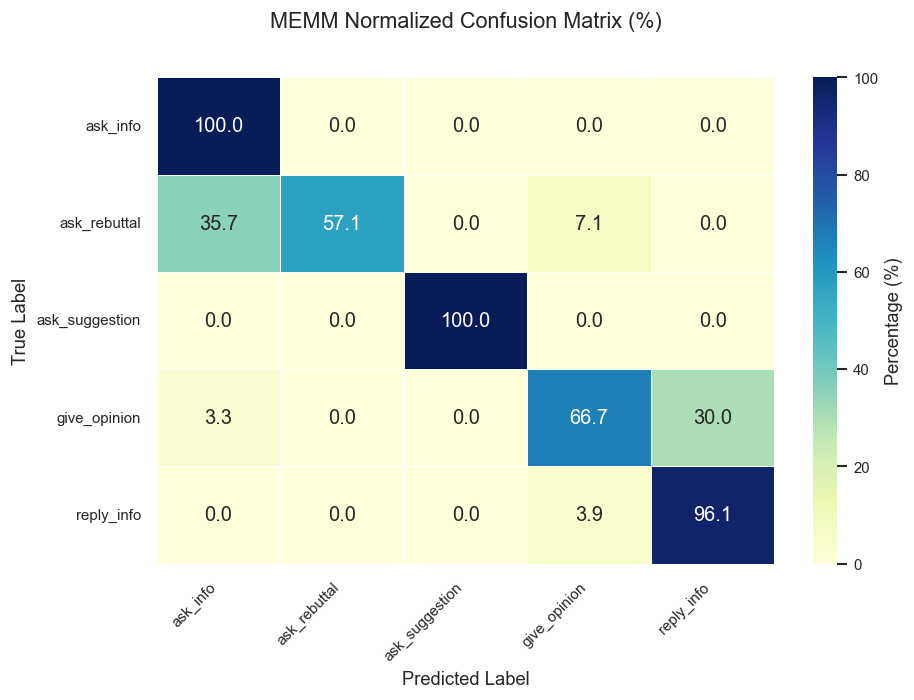

In [43]:
cm_norm = confusion_matrix(
    y_true_flat,
    y_pred_flat,
    labels=labels,
    normalize="true"
) * 100

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=labels,
    columns=labels
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm_norm_df,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="MEMM Normalized Confusion Matrix (%)",
    xlabel="Predicted Label",
    ylabel="True Label",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()

#### Per-label F1-score

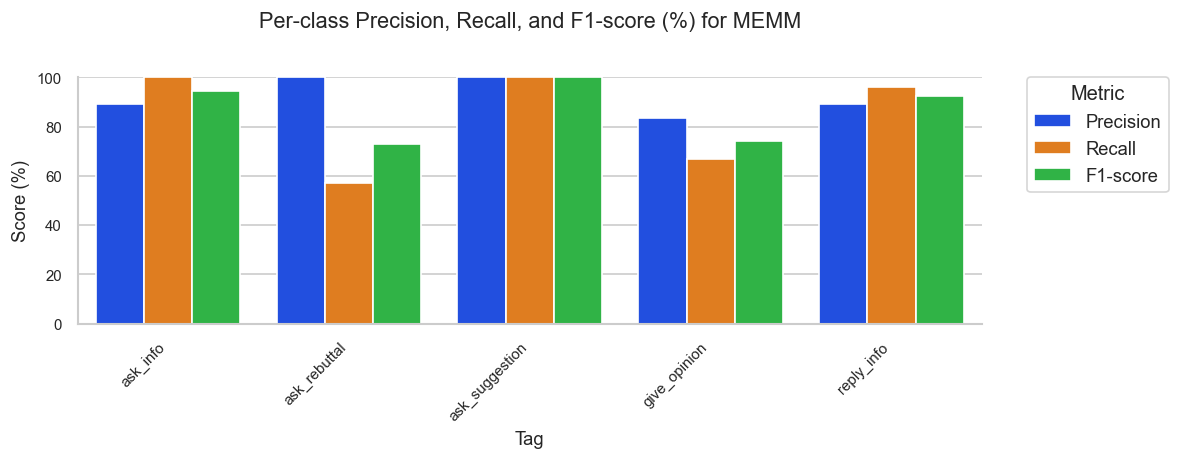

,tag,Precision,Recall,F1-score,Support
0,ask_info,0.892857,1.000000,0.943396,50
1,ask_rebuttal,1.000000,0.571429,0.727273,14
2,ask_suggestion,1.000000,1.000000,1.000000,6
3,give_opinion,0.833333,0.666667,0.740741,30
4,reply_info,0.890244,0.960526,0.924051,76


In [65]:
from sklearn.metrics import precision_recall_fscore_support

# Compute MEMM per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_true_flat,
    y_pred_flat,
    labels=labels,
    zero_division=0
)

memm_class_metrics = pd.DataFrame({
    "tag": labels,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})

# Convert to long format for seaborn
memm_class_metrics_long = memm_class_metrics.melt(
    id_vars=["tag", "Support"],
    value_vars=["Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Score"
)

# Convert scores to percentage
memm_class_metrics_long["Score"] = memm_class_metrics_long["Score"] * 100

# Same high-contrast palette as HMM plot
custom_palette = "bright"

plt.figure(figsize=REPORT_FIGSIZE)

ax = sns.barplot(
    data=memm_class_metrics_long,
    x="tag",
    y="Score",
    hue="Metric",
    palette=custom_palette
)

# Give space for text labels
ax.set_ylim(0, 100)

ax.legend(
    title="Metric", 
    frameon=True, 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    borderaxespad=0.
)

# Apply your fixed style
style_report_plot(
    ax,
    title="Per-class Precision, Recall, and F1-score (%) for MEMM",
    xlabel="Tag",
    ylabel="Score (%)"
)

plt.tight_layout()
plt.show()

memm_class_metrics

#### Previous to current label transition

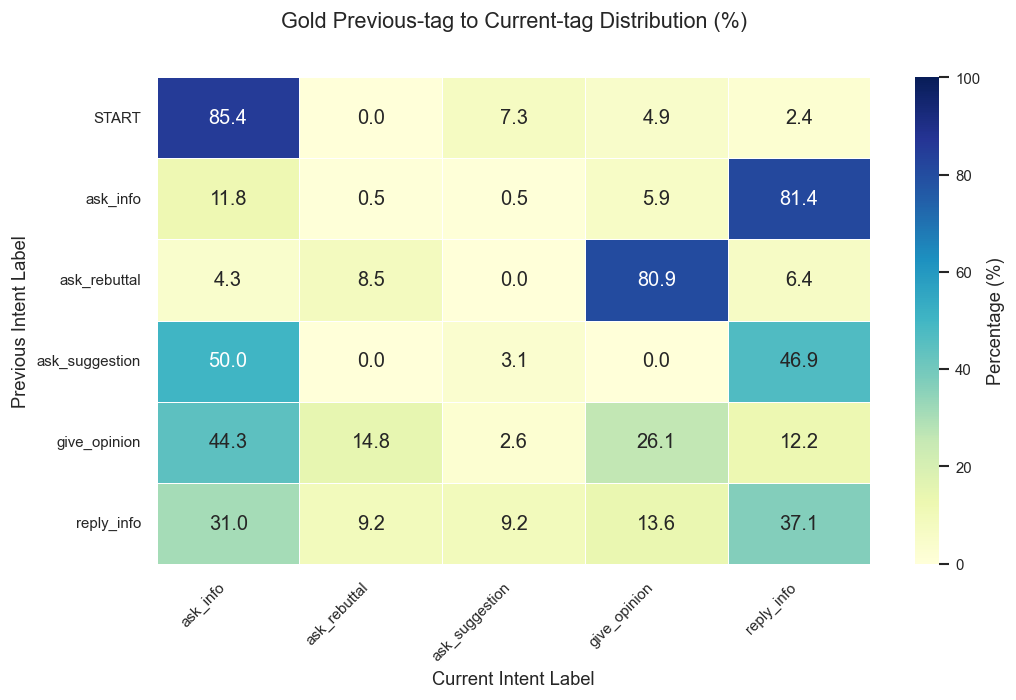

In [48]:
# Build previous gold tag from ordered dialogues
df_plot = df_temp.copy()
df_plot = df_plot.sort_values(sort_cols).reset_index(drop=True)

df_plot["prev_tag"] = (
    df_plot.groupby("dialogue_number")["tag"]
    .shift(1)
    .fillna("START")
)

transition_table = (
    pd.crosstab(df_plot["prev_tag"], df_plot["tag"], normalize="index") * 100
)

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    transition_table,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="Gold Previous-tag to Current-tag Distribution (%)",
    xlabel="Current Intent Label",
    ylabel="Previous Intent Label",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()

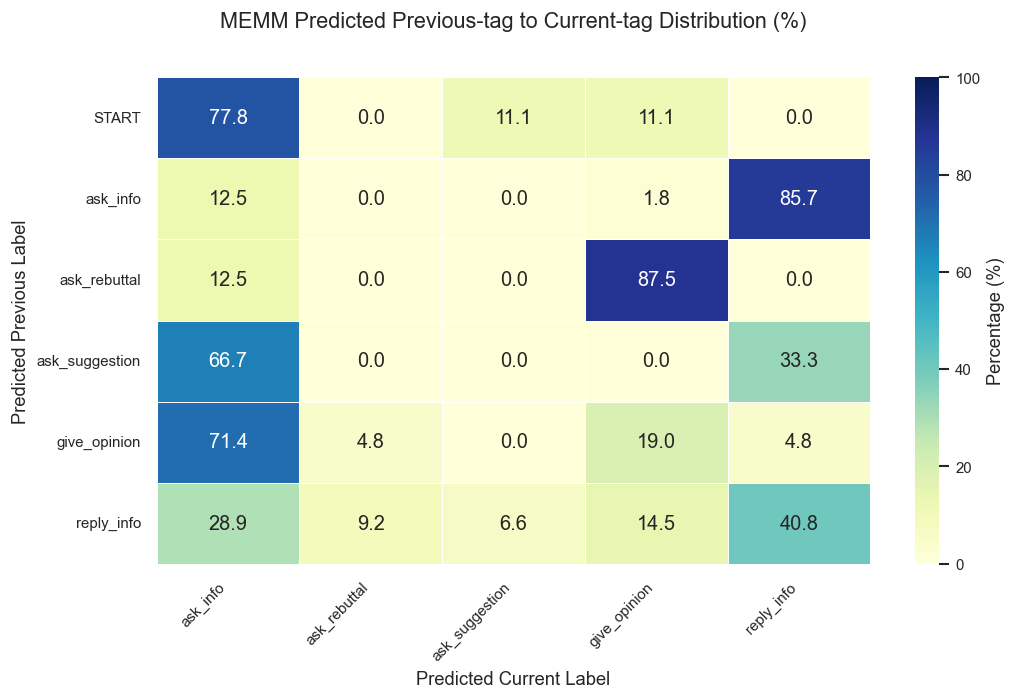

In [49]:
memm_plot_df = memm_results_df.copy()
memm_plot_df = memm_plot_df.sort_values(sort_cols).reset_index(drop=True)

memm_plot_df["prev_pred_tag"] = (
    memm_plot_df.groupby("dialogue_number")["pred_tag"]
    .shift(1)
    .fillna("START")
)

pred_transition_table = (
    pd.crosstab(memm_plot_df["prev_pred_tag"], memm_plot_df["pred_tag"], normalize="index") * 100
)

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    pred_transition_table,
    annot=True,
    fmt=".1f",
    cmap=REPORT_CMAP,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Percentage (%)"},
    vmin=0,
    vmax=100,
    ax=ax
)

style_report_plot(
    ax,
    title="MEMM Predicted Previous-tag to Current-tag Distribution (%)",
    xlabel="Predicted Current Label",
    ylabel="Predicted Previous Label",
    xtick_rotation=45,
    ytick_rotation=0
)

plt.show()